In [1]:
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [2]:
# URL for the NASA Exoplanet Archive API
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# SQL query to get all confirmed exoplanets
query = """
SELECT pl_name, hostname, pl_orbper, pl_orbpererr1, pl_orbpererr2, pl_orbsmax, pl_rade, pl_radeerr1, pl_radeerr2, pl_bmasse, pl_bmasseerr1, pl_bmasseerr2, pl_dens, pl_denserr1, pl_denserr2, pl_eqt, pl_eqterr1, pl_eqterr2, pl_orbeccen, pl_orbeccenerr1, pl_orbeccenerr2, pl_insol, pl_insolerr1, pl_insolerr2, st_spectype, st_teff, st_rad, st_mass, st_met, st_age, st_vsin, sy_dist
FROM pscomppars
"""

# Define the parameters for the API request
params = {
    "query": query,
    "format": "csv"
}

# Make the request
response = requests.get(url, params=params)

# Check for errors
response.raise_for_status()

# Convert the response content to a pandas DataFrame
df = pd.read_csv(StringIO(response.text))

# Save locally if needed
df.to_csv("./data/confirmed_exoplanets.csv", index=False)

In [3]:
print(f"Downloaded {len(df)} confirmed exoplanets.")

Downloaded 6052 confirmed exoplanets.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6052 entries, 0 to 6051
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6052 non-null   object 
 1   hostname         6052 non-null   object 
 2   pl_orbper        5737 non-null   float64
 3   pl_orbpererr1    5246 non-null   float64
 4   pl_orbpererr2    5246 non-null   float64
 5   pl_orbsmax       5749 non-null   float64
 6   pl_rade          6027 non-null   float64
 7   pl_radeerr1      4160 non-null   float64
 8   pl_radeerr2      4160 non-null   float64
 9   pl_bmasse        6021 non-null   float64
 10  pl_bmasseerr1    2926 non-null   float64
 11  pl_bmasseerr2    2926 non-null   float64
 12  pl_dens          5943 non-null   float64
 13  pl_denserr1      1370 non-null   float64
 14  pl_denserr2      1370 non-null   float64
 15  pl_eqt           4514 non-null   float64
 16  pl_eqterr1       1738 non-null   float64
 17  pl_eqterr2    

In [ ]:
def filter_param(df, column, threshold):
    err1_col = column + 'err1'
    err2_col = column + 'err2'
    
    valid = df[column] != 0

    err = (abs(df[err1_col].values) + abs(df[err2_col].values)) / 2
    rel_err = err / df[column]

    mask = (rel_err < threshold) & valid

    return df[mask]

def filter_2param(df, column1, threshold1, column2, threshold2):
    def get_mask(col, threshold):
        err1_col = col + 'err1'
        err2_col = col + 'err2'
        valid = df[col] != 0
        err = (abs(df[err1_col].values) + abs(df[err2_col].values)) / 2
        rel_err = err / df[col]
        # rel_err1 = df[err1_col] / df[col]
        # rel_err2 = df[err2_col] / df[col]
        return (rel_err < threshold) & valid

    mask1 = get_mask(column1, threshold1)
    mask2 = get_mask(column2, threshold2)

    return df[mask1 & mask2]

In [ ]:
# toi 4438 has 9.4% relative error in mass and 3.8% in radius
# toi 442 has 2.9% relative error in mass and 2.4% in radius

In [6]:
# planets with equal or less error than toi-4438 in mass and radius
filter_2param(df, 'pl_bmasse', 0.094, 'pl_rade', 0.038).shape[0]

266

In [10]:
# planets with equal or less error than toi-442 in mass and radius
print(filter_2param(df, 'pl_bmasse', 0.03, 'pl_rade', 0.025).shape[0])
print(filter_2param(df, 'pl_bmasse', 0.03, 'pl_rade', 0.03).shape[0])
toi442_df = filter_2param(df, 'pl_bmasse', 0.03, 'pl_rade', 0.03)
rad_df = filter_param(df, 'pl_rade', 0.1)
mass_df = filter_param(df, 'pl_bmasse', 0.1)
rad_mass_df10 = filter_2param(df, 'pl_bmasse', 0.1, 'pl_rade', 0.1)
rad_mass_df5 = filter_2param(df, 'pl_bmasse', 0.05, 'pl_rade', 0.05)

15
21


In [8]:
#@|-----------------------------------------------------------------
#@|Boundaries of the Neptunian desert (Castro-González et al. 2024)
#@|-----------------------------------------------------------------
x_tw_low = np.linspace(-0.30, np.log10(2.97), 100)
x_tw_low = np.linspace(-0.30, 0.47, 100)
x_tw_up = np.linspace(0.120, np.log10(2.97), 100)
x_tw_up = np.linspace(0.120, 0.473, 100)

y_tw_up = -0.43 * x_tw_up + 1.14
y_tw_low = +0.55 * x_tw_low + 0.36

color_boundaries = 'black'       #Color of the computed boundaries  
style_boundaries = 'dashed'      #Style of the boundaries

toi4438_p = 7.446295
toi4438_r = (2.39, 0.09, -0.09)
toi4438_m = (4.77, 0.45, -0.41)
toi442_p = 4.05
toi442_r = (4.25, 0.10, -0.08)
toi442_m = (28.42, 0.81, -0.79)

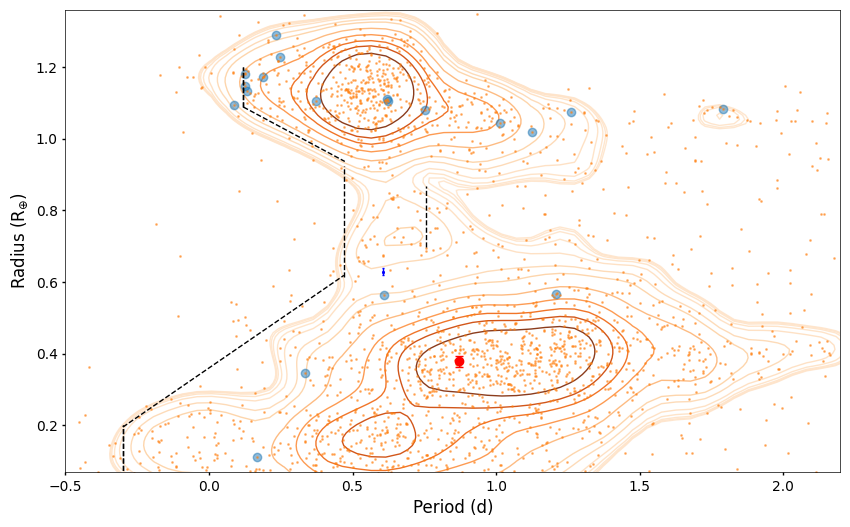

In [9]:
# plot them in period-radius space
fig, ax = plt.subplots(figsize=(10, 6))
df_ = rad_df.copy()
ax.scatter(np.log10(toi442_df['pl_orbper']), np.log10(toi442_df['pl_rade']), alpha=0.5)
ax.scatter(np.log10(df_['pl_orbper']), np.log10(df_['pl_rade']), s=1, alpha=0.5)
ax.scatter(np.log10(toi4438_p), np.log10(toi4438_r[0]), s=20, c='red', label='TOI-4438')
up = np.log10(toi4438_r[0] + toi4438_r[1]) - np.log10(toi4438_r[0])
down = np.log10(toi4438_r[0]) - np.log10(toi4438_r[0] + toi4438_r[2])
ax.errorbar(np.log10(toi4438_p), np.log10(toi4438_r[0]), 
            yerr=[[down], [up]], 
            xerr=[[0], [0]], fmt='o', color='red', 
            label='TOI-4438 (mass)', capsize=3,
            elinewidth=1, capthick=1)
ax.scatter(np.log10(toi442_p), np.log10(toi442_r[0]), s=1, c='blue', label='TOI-442')
up = np.log10(toi442_r[0] + toi442_r[1]) - np.log10(toi442_r[0])
down = np.log10(toi442_r[0]) - np.log10(toi442_r[0] + toi442_r[2])
ax.errorbar(np.log10(toi442_p), np.log10(toi442_r[0]), 
            yerr=[[down], [up]], 
            xerr=[[0], [0]], fmt='o', color='blue', markersize=1,
            label='TOI-442 (mass)', capsize=1,
            elinewidth=1, capthick=1)
ax.plot(x_tw_up, y_tw_up,  c = color_boundaries, linestyle = style_boundaries, lw = 1, zorder = 1e1000)
ax.plot(x_tw_low, y_tw_low,  c = color_boundaries, linestyle = style_boundaries, lw = 1, zorder = 1e1000)
ax.vlines(x=[np.log10(2.95), -0.30, 0.12, np.log10(5.7)], ymin=[np.log10(4.1), -0.07, 1.09, np.log10(5)],\
           ymax=[np.log10(8.4), 0.20, 1.20, np.log10(7.4)], colors = color_boundaries, \
           linestyle = style_boundaries, lw = 1, zorder = 1e10000)
ax.vlines(x=[ -0.30, 0.12], ymin=[ -0.07, 1.09],\
           ymax=[0.20, 1.20], colors = color_boundaries, \
           linestyle = style_boundaries, lw = 1, zorder = 1e10000)
sns.kdeplot(x=np.log10(rad_df['pl_orbper']), y=np.log10(rad_df['pl_rade']), cmap = 'Oranges', \
            fill = False, zorder = -1, alpha = 0.9, bw_adjust= 0.5,  linewidths = 1, \
            levels = [0,  0.163, 0.165, 0.17, 0.18, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,])
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.set_xlim(-0.5, 2.2)
ax.set_ylim(0.07, 1.36)
ax.set_xlabel('Period (d)', fontsize = 12)
ax.set_ylabel(r'Radius ($\rm R_{\oplus}$)', fontsize = 12)
ax.tick_params(which='major', length = 2, color = 'k', direction = 'out', width = 1)
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(0.5)
plt.show()